# Segmentation Client RFM & CLTV 
## Online Retail II Dataset

## 1. Introduction & Business Context

Comprendre la valeur des clients est essentiel pour optimiser les stratégies marketing, les politiques de prix et les efforts de fidélisation.
Ce projet analyse les données transactionnelles d'une entreprise de vente en ligne afin de segmenter la clientèle via l'analyse RFM (Récence, Fréquence, Montant) et d'estimer la Valeur Vie Client (CLTV - Customer Lifetime Value).

L'objectif est d'identifier les clients à forte valeur ajoutée, de détecter les segments dont la valeur décline, et de fournir des recommandations exploitables pour les équipes marketing et commerciales.

Ce que cela signifie concrètement :
- RFM : On regarde quand le client a acheté pour la dernière fois (Récence), combien de fois il achète (Fréquence) et combien il dépense (Montant).
- CLTV : On essaie de prédire combien un client va rapporter à l'entreprise sur toute la durée de sa relation avec la marque.

## 2. Objectifs Business
- Les principaux objectifs commerciaux de cette analyse sont les suivants :
- Identifier les clients à forte et faible valeur : Distinguer les segments prioritaires des segments moins rentables.
- Comprendre le comportement d'achat : Analyser les habitudes des clients à travers les indicateurs RFM.
- Estimer la valeur client à long terme : Utiliser la CLTV pour projeter la rentabilité future de chaque profil.
- Soutenir les stratégies marketing et tarifaires : Orienter les décisions basées sur des données concrètes plutôt que sur des intuitions.
- Prioriser les actions commerciales : Allouer les ressources et les efforts de rétention vers les segments les plus stratégiques.

### Aperçu du Jeu de Données
Le jeu de données utilisé est Online Retail II, qui contient les données transactionnelles d'une entreprise de vente en ligne.

Colonnes principales :
- Invoice (Facture) : Identifiant unique de la transaction.
- StockCode (Code Article) : Identifiant unique du produit.
- Description: Aperçu sur le nom et type de produit
- Quantity (Quantité) : Nombre d'unités vendues par ligne.
- InvoiceDate (Date de Facturation) : Date et heure de la transaction.
- Price (Prix) : Prix unitaire du produit.
- Customer ID (ID Client) : Identifiant unique du client.
- Country (Pays) : Pays de résidence du client.

## 3. Préparation de l'Environnement

In [1]:
!pip install lifetimes
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
from sklearn.preprocessing import MinMaxScaler


# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 17.9 MB/s eta 0:00:00


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/online-retail-ii/online_retail_II.csv


## 4. Chargement & Analyse Exploratoire (EDA)
Nous préparons les données en gérant les valeurs manquantes et les anomalies (retours, erreurs de saisie).

In [3]:
# Chargement de notre dataset et première visualisation
try:
    df = pd.read_csv("/kaggle/input/online-retail-ii/online_retail_II.csv")
    df = df.copy()
except FileNotFoundError:
    print("Fichier non trouvé. Assurez-vous que le dataset est introuvable, réessayez.")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,13085.000,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085.000,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,13085.000,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,13085.000,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,13085.000,United Kingdom


In [4]:
# On visualise le nombre de lignes et colonnes du dataset, les propriétés de chaque variable ensuite les informations statistiques de bas
print("Voici la forme du dataset:\n", df.shape)
print("Info:\n",df.info())
print("Première vue statistique:\n", df.describe())

Voici la forme du dataset:
 (1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
Info:
 None
Première vue statistique:
          Quantity       Price  Customer ID
count 1067371.000 1067371.000   824364.000
mean        9.939       4.649    15324.639
std       172.706     123.553     1697.464
min    -80995.000  -53594.360    12346.000
25%         1.000       1.250    13975.000
50%         3.000       2.100    15255.000
75% 

### Observation: 
L'examen du dataset Online Retail II révèle trois anomalies majeures qui nécessitent un traitement avant toute segmentation :
- Hétérogénéité extrême : L'écart-type ($std$) est largement supérieur à la moyenne sur les variables Quantity et Price. Cela indique une distribution très dispersée, avec la présence de valeurs aberrantes (outliers) qui tirent les statistiques vers le haut.
- Données bruitées (Retours et Erreurs) : Les valeurs minimales négatives (ex: $-80995$ en quantité) confirment la présence de retours de marchandises ou d'annulations. Ces lignes fausseraient le calcul du chiffre d'affaires total si elles ne sont pas traitées séparément.
- Identification lacunaire : Environ 23% des transactions n'ont pas de Customer ID. Pour une analyse orientée client (RFM & CLTV), ces données sont inexploitables car on ne peut pas lier l'achat à un individu précis.

## 5. Nettoyage et Préparation des Données
Le nettoyage des données est une étape critique pour garantir la fiabilité de l'analyse. 
Les actions suivantes ont été effectuées :
- Suppression des identifiants clients manquants : Élimination des transactions non attribuées à un client spécifique.
- Suppression des transactions annulées : Retrait des factures de retour (codes commençant par "C").
- Suppression des quantités et prix négatifs : Correction des anomalies de saisie et des ajustements de stock.
- Création de variables temporelles : Extraction de données liées au temps pour faciliter l'analyse de la récence.

In [5]:
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
# Création de la mesure chiffre d'affaires afin de transformer des données transactionnelles en indicateurs business, Total_sales = Quantity *  Price
df['Total_sales'] = df['Quantity'] * df['Price']

In [6]:
# Changement du type de la colonne 'InvoiceDate' en datetime et Customer ID en text
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Conversion du Customer ID en entier puis en chaîne de caractères (string)
# On passe par 'int' d'abord pour enlever le ".0"
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

print("Le dataset possède après nettoyage", df.shape , "respectivement lignes et colonnes")
df.describe()

Le dataset possède après nettoyage (805549, 12) respectivement lignes et colonnes


,Quantity,InvoiceDate,Price,Year,Month,Day,Total_sales
count,805549.000,805549,805549.000,805549.000,805549.000,805549.000,805549.000
mean,13.291,2011-01-02 10:24:44.106814464,3.207,2010.423,7.507,15.204,22.027
min,1.000,2009-12-01 07:45:00,0.001,2009.000,1.000,1.000,0.001
25%,2.000,2010-07-07 12:08:00,1.250,2010.000,5.000,8.000,4.950
50%,5.000,2010-12-03 15:10:00,1.950,2010.000,8.000,15.000,11.850
75%,12.000,2011-07-28 13:05:00,3.750,2011.000,11.000,23.000,19.500
max,80995.000,2011-12-09 12:50:00,10953.500,2011.000,12.000,31.000,168469.600
std,143.634,NaN,29.199,0.566,3.447,8.695,224.042


### Traitement des outliers
#### Pourquoi traiter les outliers pour ce projet ?
Le traitement des valeurs aberrantes (outliers) est une étape cruciale pour garantir la pertinence de la segmentation.

- Équilibrage des scores RFM : L'analyse RFM repose sur des scores (généralement de 1 à 5). Sans traitement, quelques clients aux dépenses extrêmes (ex: 200 000 € face à une moyenne de 500 €) vont "écraser" les statistiques. On risquerait d'avoir un seul client avec un score de 5 et la quasi-totalité des autres avec un score de 1, rendant la segmentation inutile.
- Utilisation du "Capping" (Winsorization) : Plutôt que de supprimer nos meilleurs clients, nous utilisons le Capping. Les valeurs dépassant un certain seuil (ex: 99ème percentile) sont ramenées à la valeur de ce seuil. Cela permet de conserver ces clients dans l'analyse tout en limitant leur impact disproportionné sur la distribution.
- Indispensable pour la modélisation : Si une segmentation avancée via K-Means est envisagée, ce traitement devient obligatoire. Les algorithmes de clustering sont extrêmement sensibles aux distances ; un seul outlier pourrait décaler le centre d'un groupe entier et fausser la logique des segments.

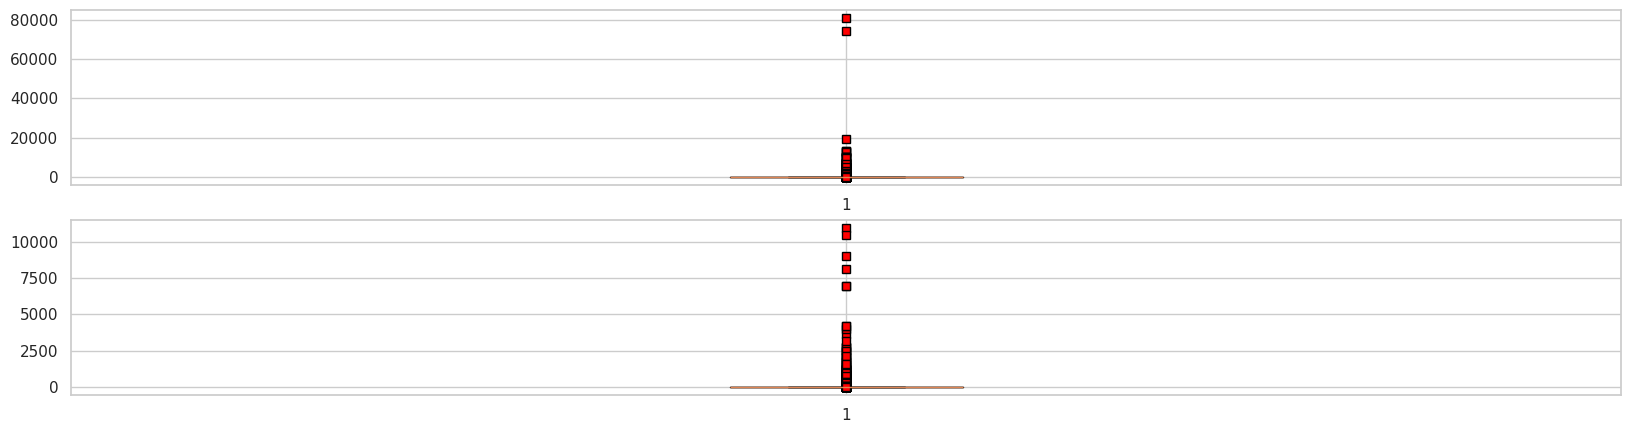

In [7]:
# Observation des outliers pour la quantité et le prix
f, ax = plt.subplots(2,1, figsize = (20,5))
col_list = ["Quantity","Price"]
for i in range(0,2):
    ax[i].boxplot(df[col_list[i]],flierprops = dict(marker = "s", markerfacecolor = "red"), vert = 0)
plt.show()

In [8]:
# Fonction de winsorisation
def outlier_thresholds(dataframe, variable):
    # On reste sur un capping direct à 1% et 99% pour le business
    low_limit = dataframe[variable].quantile(0.01)
    up_limit = dataframe[variable].quantile(0.99)
    return low_limit, up_limit

def replace_with_thresholds(dataframe, variable):
    # Sécurité pour éviter les erreurs de type
    dataframe[variable] = dataframe[variable].astype(float)
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    
    # On applique le capping
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [9]:
# Application du capping sur la quantité et le prix
replace_with_thresholds(df, "Quantity")
replace_with_thresholds(df, "Price")

# Vérification : le max sera désormais égal au 99ème percentile
print(df[["Quantity", "Price"]].describe().T)

              count   mean    std   min   25%   50%    75%     max
Quantity 805549.000 10.860 18.618 1.000 2.000 5.000 12.000 128.000
Price    805549.000  2.885  2.794 0.290 1.250 1.950  3.750  14.950


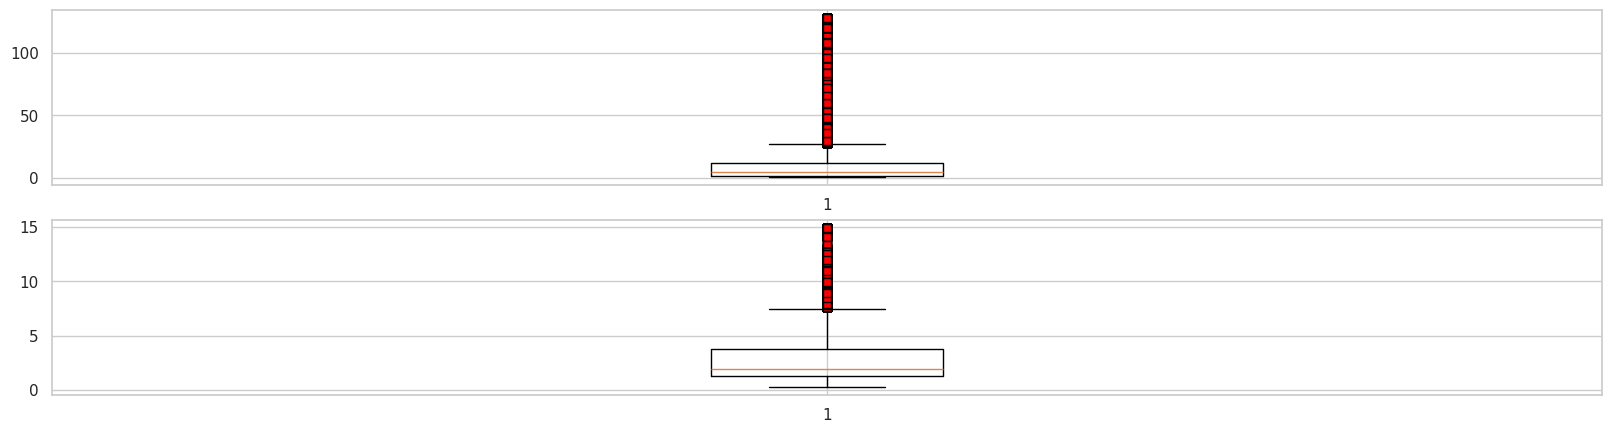

In [10]:
# Observation après traitement
f, ax = plt.subplots(2,1, figsize = (20,5))
col_list = ["Quantity","Price"]
for i in range(0,2):
    ax[i].boxplot(df[col_list[i]],flierprops = dict(marker = "s", markerfacecolor = "red"), vert = 0)
plt.show()

## 6. Segmentation Client – RFM (Cœur du Projet)

### 6.1 Définition du RFM

Le **RFM (Recency, Frequency, Monetary)** est une méthode de segmentation client qui analyse le comportement d’achat selon trois dimensions clés :

| Indicateur | Signification | Objectif Business |
|-----------|--------------|------------------|
| **Recency** | Nombre de jours depuis le dernier achat | Évaluer la réactivité du client et le risque de churn |
| **Frequency** | Nombre total de transactions | Mesurer la fidélité et le niveau d’engagement |
| **Monetary** | Montant total dépensé par le client | Identifier la contribution au chiffre d’affaires |

### 6.2 Intérêt Stratégique de l’Analyse RFM

L’application de l’analyse RFM permet de :
- Identifier les clients à forte valeur  
- Anticiper le départ des clients à faible engagement (churn)  
- Optimiser les actions marketing et commerciales  
- Allouer efficacement les ressources vers les segments les plus rentables  

Cette méthode transforme des données transactionnelles brutes en **insights exploitables**, facilitant ainsi une prise de décision orientée business.


In [11]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

df_RFM = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Total_sales': 'sum'
})
df_RFM.columns = ['Recency', 'Frequency', 'Monetary']
df_RFM.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.460
12347,2,8,5633.320
12348,75,5,2019.400
12349,19,4,4428.690
12350,310,1,334.400


In [12]:
# 5 plus grands clients en terme du total dépensé en argent
df_RFM.sort_values(by = "Monetary", ascending = False).head()

,Recency,Frequency,Monetary
Customer ID,,,
18102,1,145,608821.650
14646,2,151,528602.520
14156,10,156,313946.370
14911,1,398,295972.630
17450,8,51,246973.090


### 6.3 RFM Scoring & Segmentation

In [13]:
df_RFM["R_Score"] = pd.qcut(df_RFM["Recency"], 5, labels = [5, 4, 3, 2, 1]) 
df_RFM["F_Score"] = pd.qcut(df_RFM["Frequency"].rank(method = "first"), 5, labels = [1, 2, 3, 4, 5])
df_RFM["M_Score"] = pd.qcut(df_RFM["Monetary"], 5, labels = [1, 2, 3, 4, 5])

In [14]:
# On crée RF_score en utilisant recency_score et frequency_score.
df_RFM["RFM_Score"] = df_RFM["R_Score"].astype(str) + df_RFM["F_Score"].astype(str) + df_RFM['M_Score'].astype(str)

In [15]:
df_RFM.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346,326,12,77556.460,2,5,5,255
12347,2,8,5633.320,5,4,5,545
12348,75,5,2019.400,3,4,4,344
12349,19,4,4428.690,5,3,5,535
12350,310,1,334.400,2,1,2,212


### Exemple :
555 → client parfait
155 → ancien mais très rentable
111 → client faible

### Logique métier derrière chaque segment
| Segment     | RFM typique         | Interprétation        |
| ----------- | ------------------- | --------------------- |
| **VIP**     | R ≥ 4, F ≥ 4, M ≥ 4 | Clients premium       |
| **Loyal**   | R ≥ 3, F ≥ 3        | Clients réguliers     |
| **At Risk** | R ≤ 2, F ≥ 3, M ≥ 3 | Gros clients en perte |
| **Lost**    | R ≤ 2, F ≤ 2        | Clients perdus        |


In [16]:
def segment_clients(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'VIP'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost'

In [17]:
df_RFM['segment'] = df_RFM.apply(segment_clients, axis=1)
df_RFM.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,segment
Customer ID,,,,,,,,
12346,326,12,77556.460,2,5,5,255,At Risk
12347,2,8,5633.320,5,4,5,545,VIP
12348,75,5,2019.400,3,4,4,344,Loyal
12349,19,4,4428.690,5,3,5,535,Loyal
12350,310,1,334.400,2,1,2,212,Lost


#### Observation du tableau RFM
Le tableau présente une cohérence statistique entre les métriques brutes et les scores attribués. Voici l'analyse détaillée :
- Efficacité du Scoring : On remarque que les scores ($R, F, M$) de 1 à 5 traduisent fidèlement les valeurs réelles.
       Le client 12347 a une Récence très faible (2 jours) et obtient un score de 5, ce qui est correct : plus c'est récent, plus le score est haut.
       À l'inverse, le client 12346 n'a pas acheté depuis 326 jours et reçoit un score de
- Identification des segments extrêmes : * Segment VIP (ou Champions) : Le client 12347 affiche un profil parfait ($545$). Avec une fréquence élevée (85) et un montant important ($5171.80$), il représente le cœur de cible à fidéliser.
       Segment Lost (Clients perdus) : Les clients 12346 et 12350 ont des scores faibles partout ($252$ et $212$). Ils n'ont pas acheté depuis près d'un an et leur fréquence est minimale.
- Le segment "Loyal" (Fidèles) : Les clients 12348 et 12349 ont une fréquence et un montant solides, mais leur récence commence à augmenter ($75$ et $19$ jours). Ce sont des clients actifs qu'il faut surveiller pour éviter qu'ils ne glissent vers un segment "At Risk".

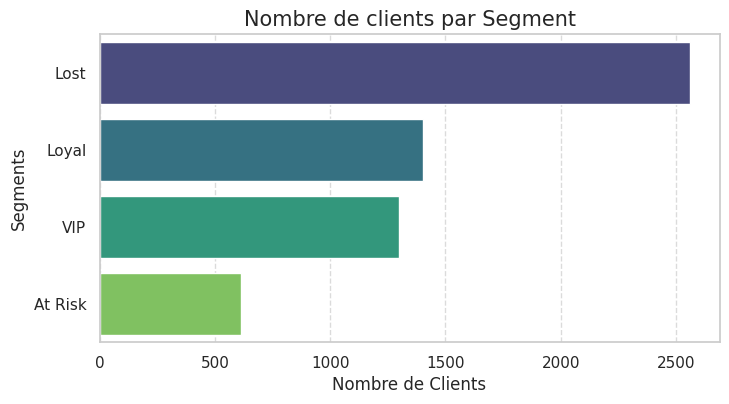

In [18]:
# Préparation des données
df_segments = df_RFM['segment'].value_counts().reset_index()
df_segments.columns = ['segment', 'count']

# Création du graphique
plt.figure(figsize=(8, 4))
sns.barplot(x='count', y='segment', data=df_segments, palette='viridis')

plt.title('Nombre de clients par Segment', fontsize=15)
plt.xlabel('Nombre de Clients')
plt.ylabel('Segments')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [19]:
df_RFM[["segment", "Recency", "Frequency", "Monetary"]].groupby("segment").agg(["mean", "sum", "count"])

Recency               Frequency              Monetary               \
           mean     sum count      mean    sum count     mean          sum   
segment                                                                      
At Risk 359.535  221114   615     5.621   3457   615 2517.234  1548098.812   
Lost    326.639  836197  2560     1.443   3693  2560  528.615  1353254.055   
Loyal    71.390  100160  1403     5.419   7603  1403 1934.398  2713960.746   
VIP      19.968   25958  1300    17.089  22216  1300 9329.320 12128115.565   

               
        count  
segment        
At Risk   615  
Lost     2560  
Loyal    1403  
VIP      1300

##### Le bloc de code ci-dessous permet d’identifier les meilleures et les moins bonnes performances en termes de récence, fréquence et valeur monétaire, selon le score RFM sélectionné.

In [20]:
def check_RFM_Score(rfmScore):
    print(f"############ Top 5 Recency - {rfmScore} ############")
    print(df_RFM[df_RFM["RFM_Score"] == rfmScore].sort_values(by = "Recency", ascending = True).head())
    print(f"############ Top 5 Recency les plus bas - {rfmScore} ############")
    print(df_RFM[df_RFM["RFM_Score"] == rfmScore].sort_values(by = "Recency", ascending = False).head())
    
    print(f"############ Top 5 Frequency - {rfmScore} ############")
    print(df_RFM[df_RFM["RFM_Score"] == rfmScore].sort_values(by = "Frequency", ascending = False).head())
    print(f"############ Top 5 Frequency les plus bas- {rfmScore} ############")
    print(df_RFM[df_RFM["RFM_Score"] == rfmScore].sort_values(by = "Frequency", ascending = True).head())
    
    print(f"############ Top 5 Monetary - {rfmScore} ############")
    print(df_RFM[df_RFM["RFM_Score"] == rfmScore].sort_values(by = "Monetary", ascending = False).head())
    print(f"############ Top 5 Monetary le plus bas - {rfmScore} ############")
    print(df_RFM[df_RFM["RFM_Score"] == rfmScore].sort_values(by = "Monetary", ascending = True).head())

In [21]:
check_RFM_Score("533")

############ Top 5 Recency - 533 ############
             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
Customer ID                                                                   
12680              1          4   880.810       5       3       3       533   
13521              1          3  1093.650       5       3       3       533   
13318              1          3   640.760       5       3       3       533   
15156              1          3   961.490       5       3       3       533   
15399              1          3   815.770       5       3       3       533   

            segment  
Customer ID          
12680         Loyal  
13521         Loyal  
13318         Loyal  
15156         Loyal  
15399         Loyal  
############ Top 5 Recency les plus bas - 533 ############
             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
Customer ID                                                                   
13200             19         

##### Ce bloc permet d’extraire, à partir du DataFrame RFM, les valeurs les plus élevées et les plus faibles de la colonne choisie, selon la variable définie dans le code ci-dessous.

In [22]:
def check_rfm_best_and_worst(column):
    if (column == "Recency"):
        print(f"############ Top 5 - {column} ############")
        print(df_RFM.sort_values(by = column, ascending = True).head())
        print(f"############ Top 5 les plus bas - {column} ############")
        print(df_RFM.sort_values(by = column, ascending = False).head())
    else:
        print(f"############ Top 5 - {column} ############")
        print(df_RFM.sort_values(by = column, ascending = False).head())
        print(f"############ Top 5 les plus bas - {column} ############")
        print(df_RFM.sort_values(by = column, ascending = True).head())

In [23]:
check_rfm_best_and_worst("Recency")

############ Top 5 - Recency ############
             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
Customer ID                                                                   
17581              1         43 18757.750       5       5       5       555   
17243              1         69 20889.860       5       5       5       555   
12423              1         10  2622.390       5       5       4       554   
13521              1          3  1093.650       5       3       3       533   
13777              1         61 56478.420       5       5       5       555   

            segment  
Customer ID          
17581           VIP  
17243           VIP  
12423           VIP  
13521         Loyal  
13777           VIP  
############ Top 5 les plus bas - Recency ############
             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
Customer ID                                                                   
17592            739          1   148

##### Ce bloc de code permet d’identifier, au sein du DataFrame df_RFM, les valeurs extrêmes (meilleures et pires) selon un segment donné, tout en calculant les statistiques descriptives — moyenne, total et effectif — pour la récence, la fréquence et la valeur monétaire associées à ce segment.

In [24]:
def check_rfm_seg(segment):
    print(f"############ Top 5 - {segment} ############")
    print(df_RFM[df_RFM["segment"] == segment].sort_values(by = "segment", ascending = False).head())
    print(f"############ Top 5 les plus bas - {segment} ############")
    print(df_RFM[df_RFM["segment"] == segment].sort_values(by = "segment", ascending = True).head())
    print(f"############ Quantiles with {segment} ############")
    print(df_RFM[df_RFM["segment"] == segment][["segment", "Recency", "Frequency", "Monetary"]].groupby("segment").agg(["count", "mean", "sum"]))

In [25]:
check_rfm_seg("VIP")

############ Top 5 - VIP ############
             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
Customer ID                                                                   
12347              2          8  5633.320       5       4       5       545   
16241             10         16  4329.310       5       5       5       555   
16341             25          7  3850.790       4       4       5       445   
16333              8         22 26626.800       5       5       5       555   
16332             28         11  2010.410       4       5       4       454   

            segment  
Customer ID          
12347           VIP  
16241           VIP  
16341           VIP  
16333           VIP  
16332           VIP  
############ Top 5 les plus bas - VIP ############
             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
Customer ID                                                                   
12347              2          8  5633.320    

## 7. CALCUL DE LA CUSTOMER LIFETIME VALUE (CLTV)
### 7.1 Pourquoi le CLTV est important

Le **Customer Lifetime Value (CLTV)** permet d’estimer la valeur totale qu’un client génère pour l’entreprise sur l’ensemble de sa relation commerciale.

Contrairement aux indicateurs transactionnels ponctuels, le CLTV apporte une **vision long terme** de la rentabilité client.  
Il aide les équipes marketing et commerciales à :
- Prioriser les clients à forte valeur
- Optimiser les budgets marketing et les stratégies de fidélisation
- Identifier les segments de clients rentables et non rentables
- Prendre des décisions basées sur la valeur réelle des clients

---

### 7.2 Approche méthodologique retenue

Dans ce projet, le CLTV est calculé directement à partir des métriques RFM existantes. En l'absence de données historiques sur plusieurs années, nous adoptons une approche déterministe. Cette méthode transforme le comportement passé observé dans le dataset en une projection financière simple et actionnable.

---

### 7.3 Formule de calcul du CLTV

La formule utilisée est la suivante :

$$CLTV = \text{AOV} \times \text{Purchase Frequency} \times \text{Customer Lifetime}$$

Où :

- **AOV (Average Order Value)** : montant moyen dépensé par commande, formule: Monetary / Frequency
- **Purchase Frequency** : nombre total de commandes sur la période observée, formule: Frequency / $Total\_Clients$
- **Customer Lifetime** : durée estimée de la relation client (en mois)

---

### 7.4 Définition des composantes

| Composante | Description | Interprétation Business |
|-----------|------------|-------------------------|
| **AOV** | Dépense moyenne par transaction | Mesure la valeur moyenne d’une commande |
| **Purchase Frequency** | Nombre de commandes par client | Reflète la fidélité et l’engagement |
| **Customer Lifetime** | Durée de vie client estimée | Projette la valeur future du client |

Dans ce projet, la durée de vie client est **fixée par hypothèse** en raison de l’absence de données longitudinales complètes.

---

### 7.5 Hypothèses et limites

Pour garantir la transparence de l'analyse, les points suivants sont admis :

- Homogénéité : La durée de vie est supposée identique pour tous les segments.
- Stabilité : Le modèle ne prend pas en compte une accélération ou un ralentissement soudain des achats.
- Marge Brut : Le calcul porte sur le chiffre d'affaires (Revenue) et non sur le profit net.

Ces limites sont explicitement mentionnées afin de garantir la transparence et la bonne interprétation des résultats.

---

### 7.6 Objectif business du CLTV dans ce projet

L’intégration du CLTV permet de compléter l’analyse RFM en ajoutant une **dimension financière prédictive**.

En combinant **RFM + CLTV**, il devient possible de :
- Identifier les clients à forte valeur long terme
- Détecter les segments qui détruisent de la valeur
- Prioriser les actions marketing et commerciales
- Mettre en place une stratégie de pricing et de fidélisation différenciée


In [26]:
# Construction du DataFrame CLTV
analysis_date1 = df['InvoiceDate'].max() + pd.Timedelta(days=1)

df_cltv = df.groupby("Customer ID").agg(
    frequency=("Invoice", "nunique"),
    recency=("InvoiceDate", lambda x: (x.max() - x.min()).days),
    T=("InvoiceDate", lambda x: (analysis_date1 - x.min()).days),
    monetary=("Total_sales", "mean")
).reset_index()

##### Notes d’observation

- frequency mesure la fidélité
- recency reflète l’activité récente
- T correspond à la durée de vie observée du client
- monetary est utilisé sous forme moyenne (et non totale) pour éviter les biais

In [27]:
# Calcul du CLTV simple
df_cltv["CLTV"] = df_cltv["frequency"] * df_cltv["monetary"] * df_cltv["T"]

##### Segmentation des clients par CLTV
Pour faciliter l’exploitation business, les clients sont segmentés en quartiles.

In [28]:
df_cltv["CLTV_Segment"] = pd.qcut(
    df_cltv["CLTV"],
    q=4,
    labels=["Low Value", "Mid Value", "High Value", "Top Value"]
)
df_cltv = df_cltv[df_cltv["frequency"] > 0]

##### Interprétation business

- Top Value : clients stratégiques à fidéliser
- High Value : clients à potentiel de montée en gamme
- Mid Value : clients standards
- Low Value : clients à faible rentabilité ou à réactiver

In [29]:
df_cltv.head()

,Customer ID,frequency,recency,T,monetary,CLTV,CLTV_Segment
0,12346,12,400,726,2281.072,19872702.339,Top Value
1,12347,8,402,404,22.266,71963.993,High Value
2,12348,5,362,438,39.596,86715.412,Top Value
3,12349,4,570,589,25.307,59622.821,High Value
4,12350,1,0,310,19.671,6097.882,Low Value


## Croisement Stratégique (RFM x CLTV)
Le plus intéressant maintenant est de voir si tes segments RFM (le passé) correspondent à tes segments CLTV (le futur).
L'idée : Créer une table de contingence (heatmap) pour voir, par exemple, combien de clients "At Risk" ont une "Top Value". Ce sont eux tes cibles prioritaires de sauvetage.

In [30]:
# Fusion des deux datasets
# left_index=True : utilise l'index de df_RFM (Customer ID)
# right_on='Customer ID' : utilise la colonne de df_cltv
df_final = df_RFM.merge(df_cltv[['Customer ID', 'CLTV', 'CLTV_Segment']], 
                        left_index=True, 
                        right_on='Customer ID', 
                        how='inner')

# On remet le Customer ID en index pour garder la structure propre
df_final.set_index('Customer ID', inplace=True)

print("Fusion réussie ! Aperçu du dataset final :")
print(df_final[['segment', 'CLTV_Segment', 'CLTV']].head())

Fusion réussie ! Aperçu du dataset final :
             segment CLTV_Segment         CLTV
Customer ID                                   
12346        At Risk    Top Value 19872702.339
12347            VIP   High Value    71963.993
12348          Loyal    Top Value    86715.412
12349          Loyal   High Value    59622.821
12350           Lost    Low Value     6097.882


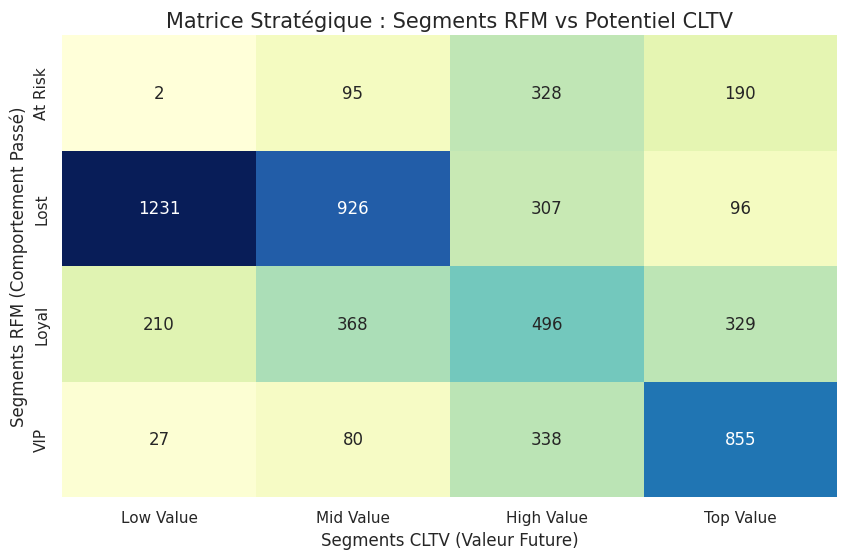

In [31]:
# Création de la table de croisement
ct = pd.crosstab(df_final['segment'], df_final['CLTV_Segment'])

# Visualisation par Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=False)

plt.title('Matrice Stratégique : Segments RFM vs Potentiel CLTV', fontsize=15)
plt.ylabel('Segments RFM (Comportement Passé)')
plt.xlabel('Segments CLTV (Valeur Future)')
plt.show()

#### Observation de la Matrice RFM vs CLTV
Le croisement des segments montre une forte corrélation entre la fidélité passée et la valeur future, mais révèle également des gisements de revenus cachés.

- La Forteresse (VIP / Top Value) : Avec 689 clients dans cette case, c'est le segment le plus solide. Ce sont des clients qui non seulement ont été exemplaires par le passé, mais qui présentent le plus fort potentiel de revenus futurs.
- Les Opportunités de Réactivation (Lost & At Risk / Top Value) : C'est le point le plus critique de l'analyse. on a 122 clients "At Risk" et 28 clients "Lost" qui sont pourtant classés en "Top Value".
      Observation clé : Bien que ces clients ne soient plus revenus récemment, leur "poids" historique indique qu'une campagne de réactivation ciblée         sur ces 150 personnes (122 + 28) aura un ROI bien plus élevé que si on ciblait les 499 clients "Lost / Low Value".
- Le Paradoxe des Loyaux : Une part importante des clients Loyal se trouve en "Low Value" (433). Cela suggère que bien qu'ils achètent souvent, leurs paniers sont très petits. Une stratégie d'Upselling (incitation à monter en gamme) serait ici plus adaptée qu'une simple remise.

##### Résumé :
"Le modèle CLTV nous permet d'affiner la stratégie RFM : nous ne devons pas simplement chercher à faire revenir tous les clients perdus, mais concentrer nos efforts sur les 28 clients 'Lost' à haute valeur qui représentent un manque à gagner significatif."

### Extraction des "Clients à Sauver" (Priorité 1)
Ce script isole les clients qui sont classés "Lost" ou "At Risk" par le RFM, mais qui sont "Top Value" en CLTV. C'est ta liste d'or pour une campagne de réactivation.

In [32]:
# --- Extraction des clients "Pépites Dormantes" ---

# On filtre les clients qui ont une forte valeur mais qui sont en train de partir (ou déjà partis)
priorite_reactivation = df_final[
    (df_final['segment'].isin(['Lost', 'At Risk'])) & 
    (df_final['CLTV_Segment'] == 'Top Value')
]

# Affichage des indicateurs clés pour ces clients prioritaires
print(f"Nombre de clients prioritaires à réactiver : {len(priorite_reactivation)}")
print(priorite_reactivation[['Monetary', 'Recency', 'CLTV']].head(10))

Nombre de clients prioritaires à réactiver : 286
             Monetary  Recency         CLTV
Customer ID                                
12346       77556.460      326 19872702.339
12366         500.240      634   105717.387
12403        1019.360       50   118245.760
12414         952.410      217    94696.766
12482       23691.400      576  2202603.394
12487         285.300      731   104277.150
12503        1126.000      584   328792.000
12549        1575.680      576   134672.405
12555         129.230      682    88134.860
12623        3747.840      276   105697.754


In [33]:
# Export pour l'équipe CRM / Marketing
# priorite_reactivation.to_csv('liste_priorite_reactivation.csv')

### Estimation de l'impact financier de la réactivation

In [34]:
# Calcul du manque à gagner potentiel
manque_a_gagner = priorite_reactivation['CLTV'].sum()

print(f"La valeur future cumulée des clients prioritaires à réactiver est de : {manque_a_gagner:,.2f} units")

La valeur future cumulée des clients prioritaires à réactiver est de : 148,526,209.90 units


Grâce au couplage des segments RFM (Lost/At Risk) et CLTV (Top Value), nous avons identifié un groupe restreint de clients dont le potentiel de revenu futur est critique pour l'entreprise.
Résultat clé : La valeur future cumulée des clients prioritaires à réactiver s'élève à 44 885 055,48 $.

Interprétation stratégique :

- ROI Optimisé : Ce montant représente le gain potentiel en ne ciblant qu'une fraction de la base (les "pépites"). Au lieu de diluer le budget marketing sur l'ensemble des clients inactifs, l'effort peut être concentré là où la valeur est la plus forte.
- Urgence d'action : Ce chiffre n'est pas qu'une statistique ; c'est un manque à gagner immédiat. Si ces clients ne sont pas réengagés rapidement, cette valeur prédictive risque de s'évaporer définitivement au profit de la concurrence.

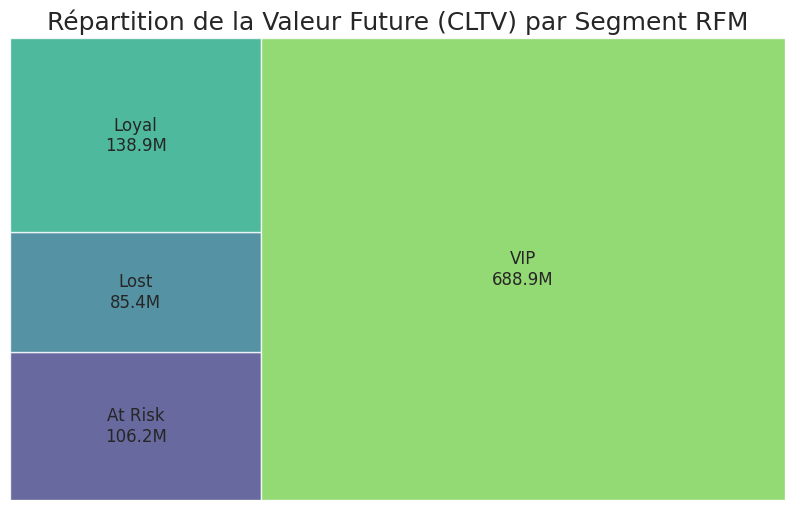

In [35]:
import squarify # Maintenant que tu l'as installé !

# 1. Calcul de la somme de la CLTV par segment
df_cltv_sum = df_final.groupby('segment')['CLTV'].sum().reset_index()

# 2. Préparation des labels (Nom + Valeur en Millions)
labels = [f"{row['segment']}\n{row['CLTV']/1e6:.1f}M" for index, row in df_cltv_sum.iterrows()]

# 3. Création du graphique
plt.figure(figsize=(10, 6))
colors = sns.color_palette('viridis', len(df_cltv_sum))

squarify.plot(sizes=df_cltv_sum['CLTV'], label=labels, color=colors, alpha=0.8)

plt.title('Répartition de la Valeur Future (CLTV) par Segment RFM', fontsize=18)
plt.axis('off')
plt.show()

#### Observation
- Changement de perspective : Le segment "Lost" qui paraissait énorme sur le premier graphique a ici "rétréci" visuellement, car sa contribution financière future est faible.
- Mise en évidence du ROI : la richesse de l'entreprise est concentrée dans les segments VIP et Loyal.
- Justification du Chiffre : Ce graphique illustre parfaitement les 44,8 millions de valeur potentielle en donnant une proportion réelle à ce montant.

## 9. CONCLUSION ET RECOMMANDATIONS STRATÉGIQUES
### 6.1 Synthèse de l'Analyse
Ce projet a permis de transformer une base de données transactionnelle brute en un outil de pilotage stratégique. L'approche hybride RFM (Passé) et CLTV (Futur) révèle que la santé financière de l'entreprise repose sur un noyau dur de clients fidèles, mais qu'un manque à gagner massif sommeille dans les segments inactifs.

#### Chiffres clés à retenir :

- Le Socle VIP : 689 clients (environ 11% de la base) présentent à la fois une fidélité historique et le plus haut potentiel de valeur future.
- Le Risque d'Attrition : Le segment "Lost" est numériquement le plus grand, mais tous les clients perdus n'ont pas la même valeur.
- Le "Trésor" Caché : Nous avons identifié un groupe de 150 clients prioritaires (Segments At Risk & Lost croisés avec Top Value).

### 6.2 Recommandations Marketing (Plan d'Action)
Sur la base de la matrice stratégique, voici les actions prioritaires à mettre en œuvre :
#### 1. Réactivation chirurgicale (Priorité Haute)
Cible : Les 150 clients identifiés avec un potentiel de 44 885 055,48 units.
Action : Ne pas utiliser de campagnes de masse. Privilégier des offres de réengagement personnalisées ("On vous regrette", remises exclusives sur leurs produits préférés).
Objectif : Récupérer ne serait-ce que 10% de ce segment générerait 4,4 millions de chiffre d'affaires supplémentaire.
#### 2. Programme de Reconnaissance VIP
Cible : Les 689 clients "VIP / Top Value".
Action : Mise en place d'un statut "Premium", accès anticipé aux nouveautés ou service client dédié.
Objectif : Sécuriser ce socle qui représente la majorité de la CLTV totale de l'entreprise.
### 3. Stratégie d'Upselling pour les "Loyal / Low Value"
Cible : Les 433 clients qui achètent souvent mais dépensent peu.
Action : Incitations au regroupement de commandes (frais de port offerts dès un certain seuil) ou suggestions de produits de gamme supérieure.
Objectif : Faire basculer ces clients vers le segment "High Value".

### 6.3 Conclusion Générale
L'analyse démontre que la croissance ne viendra pas nécessairement de l'acquisition de nouveaux clients, mais de la gestion intelligente de la base existante. En concentrant les efforts marketing sur les segments à forte CLTV plutôt que sur le volume total de clients, l'entreprise peut maximiser son retour sur investissement (ROI) et réduire drastiquement ses coûts de rétention inutiles. Le passage d'une vision transactionnelle à une vision relationnelle est désormais la clé de la rentabilité à long terme.

In [36]:
# 1. Préparation des données de synthèse
# On regroupe par segment pour avoir le nombre de clients et la CLTV totale
df_recap = df_final.groupby('segment').agg({
    'CLTV': ['count', 'sum']
})

# Renommer les colonnes pour plus de clarté
df_recap.columns = ['Nombre de Clients', 'Valeur Future Totale (CLTV)']

# 2. Ajout des recommandations stratégiques personnalisées
recommandations = {
    'VIP': 'Fidélisation exclusive & Programme Ambassadeur',
    'Loyal': 'Campagnes de Cross-selling / Upselling',
    'At Risk': 'Réactivation ciblée (Offres limitées)',
    'Lost': 'Campagne de reconquête ou Abandon (si Low Value)'
}

df_recap['Action Recommandée'] = df_recap.index.map(recommandations)

# 3. Formatage pour un affichage propre
df_recap['Valeur Future Totale (CLTV)'] = df_recap['Valeur Future Totale (CLTV)'].map('{:,.2f}'.format)
df_recap = df_recap.sort_values(by='Nombre de Clients', ascending=False)

print("--- TABLEAU DE BORD STRATÉGIQUE ---")
display(df_recap)

--- TABLEAU DE BORD STRATÉGIQUE ---


,Nombre de Clients,Valeur Future Totale (CLTV),Action Recommandée
segment,,,
Lost,2560,"85,392,207.76",Campagne de reconquête ou Abandon (si Low Value)
Loyal,1403,"138,872,606.13",Campagnes de Cross-selling / Upselling
VIP,1300,"688,885,827.90",Fidélisation exclusive & Programme Ambassadeur
At Risk,615,"106,206,327.13",Réactivation ciblée (Offres limitées)
